# IE7615 Generative Project — Milestone #2
## CLIP-GPT2 Integration, Training & Decoding Strategies

**Course:** IE7615 Neural Networks/Deep Learning SEC 02, Spring 2026  
**Group 8:** Quoc Hung Le, Khoa Tran, Hassan Alfareed  
**Milestone:** #2 — Model Integration & Baseline Generation  

---

### Objective

1. Integrate CLIP image encoder with GPT-2 language decoder via a learned projection head
2. Implement prefix conditioning (embedding injection)
3. Train the captioning model on precomputed embeddings from M1
4. Generate baseline captions and compare decoding strategies (greedy, beam search, nucleus sampling)

### Architecture

```
Image -> CLIP ViT-B/32 -> 512-d -> ProjectionHead -> (B, 10, 768) prefix
                                                        |
         [prefix tokens] + [caption tokens] -> GPT-2 LM Head -> next-token prediction
```

---
## 0. Configuration & Reproducibility

In [1]:
import os
import sys
import random
import logging
import time
import json
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__")) + "/../"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


@dataclass
class TrainingConfig:
    """Extended config for M2 training. Inherits M1 values and adds training params."""

    # Paths (from M1)
    project_root: str = PROJECT_ROOT
    embeddings_dir: str = ""
    outputs_dir: str = ""
    checkpoints_dir: str = ""
    logs_dir: str = ""

    # Model (from M1)
    clip_model_name: str = "openai/clip-vit-base-patch32"
    clip_embedding_dim: int = 512
    gpt2_model_name: str = "gpt2"
    gpt2_embedding_dim: int = 768
    max_token_length: int = 50

    # Projection
    prefix_length: int = 10

    # Training
    learning_rate: float = 2e-4
    weight_decay: float = 0.01
    epochs: int = 20
    batch_size: int = 16
    warmup_ratio: float = 0.15
    early_stopping_patience: int = 3
    gradient_clip_norm: float = 1.0
    log_interval: int = 50

    # Decoding
    beam_width: int = 5
    nucleus_top_p: float = 0.9
    nucleus_temperature: float = 0.8
    max_gen_length: int = 40

    # Reproducibility
    seed: int = 42
    device: str = ""

    def __post_init__(self):
        self.embeddings_dir = os.path.join(self.project_root, "data", "embeddings")
        self.outputs_dir = os.path.join(self.project_root, "outputs")
        self.checkpoints_dir = os.path.join(self.outputs_dir, "checkpoints")
        self.logs_dir = os.path.join(self.outputs_dir, "logs")

        if not self.device:
            if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
                self.device = "mps"
            elif torch.cuda.is_available():
                self.device = "cuda"
            else:
                self.device = "cpu"


cfg = TrainingConfig()


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(cfg.seed)

for d in [cfg.checkpoints_dir, cfg.logs_dir,
          os.path.join(cfg.outputs_dir, "samples"),
          os.path.join(cfg.outputs_dir, "figures")]:
    Path(d).mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("milestone2")
logger.info(f"Device: {cfg.device}")
logger.info(f"PyTorch: {torch.__version__}")

2026-02-27 03:11:21 [INFO] Device: mps
2026-02-27 03:11:21 [INFO] PyTorch: 2.10.0


---
## 1. Load Precomputed Embeddings from Milestone #1

We load the `.pt` files saved by M1 — no CLIP recomputation needed.

In [2]:
def load_split(split_name: str, embeddings_dir: str) -> Dict:
    path = os.path.join(embeddings_dir, f"{split_name}_embeddings.pt")
    data = torch.load(path, map_location="cpu", weights_only=False)
    logger.info(f"Loaded {split_name}: {data['embeddings'].shape[0]} samples, "
                f"embedding dim {data['embeddings'].shape[1]}")
    return data


train_data = load_split("train", cfg.embeddings_dir)
val_data = load_split("val", cfg.embeddings_dir)
test_data = load_split("test", cfg.embeddings_dir)

print(f"Train embeddings: {train_data['embeddings'].shape}")
print(f"Val embeddings:   {val_data['embeddings'].shape}")
print(f"Test embeddings:  {test_data['embeddings'].shape}")
print(f"Sample caption:   '{train_data['captions'][0]}'")

2026-02-27 03:11:21 [INFO] Loaded train: 2400 samples, embedding dim 512
2026-02-27 03:11:21 [INFO] Loaded val: 300 samples, embedding dim 512
2026-02-27 03:11:21 [INFO] Loaded test: 300 samples, embedding dim 512


Train embeddings: torch.Size([2400, 512])
Val embeddings:   torch.Size([300, 512])
Test embeddings:  torch.Size([300, 512])
Sample caption:   'a man paint spattered clothing talks on a mobile phone.'


---
## 2. Dataset & Tokenizer

We build a lightweight dataset that pairs precomputed CLIP embeddings with GPT-2 tokenized captions. No images are loaded at training time.

In [3]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained(cfg.gpt2_model_name)
tokenizer.pad_token = tokenizer.eos_token
logger.info(f"Tokenizer loaded: vocab_size={tokenizer.vocab_size}, pad_id={tokenizer.pad_token_id}")


class EmbeddingCaptionDataset(Dataset):
    """Pairs precomputed CLIP embeddings with tokenized captions for training."""

    def __init__(self, data: Dict, tokenizer: GPT2Tokenizer, max_length: int):
        self.embeddings = data["embeddings"]
        self.captions = data["captions"]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.captions)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        embedding = self.embeddings[idx]
        caption = self.captions[idx]

        encoded = self.tokenizer(
            caption,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "embedding": embedding,
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }


train_dataset = EmbeddingCaptionDataset(train_data, tokenizer, cfg.max_token_length)
val_dataset = EmbeddingCaptionDataset(val_data, tokenizer, cfg.max_token_length)
test_dataset = EmbeddingCaptionDataset(test_data, tokenizer, cfg.max_token_length)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

sample = train_dataset[0]
print(f"Embedding: {sample['embedding'].shape}")
print(f"Input IDs: {sample['input_ids'].shape}")
print(f"Attention mask sum: {sample['attention_mask'].sum().item()}")

2026-02-27 03:11:23 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-02-27 03:11:23 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-02-27 03:11:23 [INFO] HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-02-27 03:11:23 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-02-27 03:11:23 [INFO] HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-02-27 03:11:23 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-02-27 03:11:2

Embedding: torch.Size([512])
Input IDs: torch.Size([50])
Attention mask sum: 12


---
## 3. Captioning Model — Prefix-Conditioned GPT-2

The model consists of three components:
1. **ProjectionHead** — maps CLIP 512-d to a sequence of GPT-2 prefix tokens (10 x 768)
2. **GPT-2 Decoder** — pretrained autoregressive language model
3. **ClipCaptionModel** — orchestrates prefix injection and caption generation

The prefix tokens are prepended to the caption token embeddings, conditioning GPT-2 on the image content. Only the ProjectionHead is trained; GPT-2 weights are frozen initially and optionally unfrozen for fine-tuning later.

In [4]:
from transformers import GPT2LMHeadModel


class ProjectionHead(nn.Module):
    """Maps CLIP embeddings to GPT-2 prefix token space.

    Input:  (B, 512)
    Output: (B, prefix_length, 768)
    """

    def __init__(self, clip_dim: int = 512, gpt2_dim: int = 768, prefix_length: int = 10):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt2_dim = gpt2_dim
        hidden = gpt2_dim * prefix_length

        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
        )

    def forward(self, clip_embedding: torch.Tensor) -> torch.Tensor:
        projected = self.projection(clip_embedding)
        return projected.view(-1, self.prefix_length, self.gpt2_dim)


class ClipCaptionModel(nn.Module):
    """End-to-end CLIP-GPT2 captioning model with prefix conditioning."""

    def __init__(self, cfg: TrainingConfig):
        super().__init__()
        self.cfg = cfg
        self.prefix_length = cfg.prefix_length

        self.projection = ProjectionHead(
            clip_dim=cfg.clip_embedding_dim,
            gpt2_dim=cfg.gpt2_embedding_dim,
            prefix_length=cfg.prefix_length,
        )

        self.gpt2 = GPT2LMHeadModel.from_pretrained(cfg.gpt2_model_name)
        self.gpt2.resize_token_embeddings(len(tokenizer))

        # Freeze GPT-2 initially
        for param in self.gpt2.parameters():
            param.requires_grad = False

        self._trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        self._total_params = sum(p.numel() for p in self.parameters())
        logger.info(f"Trainable: {self._trainable_params:,} / Total: {self._total_params:,}")

    def forward(self, embeddings: torch.Tensor, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        """Forward pass with prefix conditioning.

        1. Project CLIP embedding to prefix tokens
        2. Get GPT-2 token embeddings for caption
        3. Concatenate [prefix | caption_embeddings]
        4. Build extended attention mask
        5. Run through GPT-2 and compute loss on caption tokens only
        """
        batch_size = embeddings.shape[0]
        prefix = self.projection(embeddings)  # (B, prefix_len, 768)

        # Get GPT-2 word embeddings for caption tokens
        token_embeds = self.gpt2.transformer.wte(input_ids)  # (B, seq_len, 768)

        # Concatenate prefix + caption embeddings
        combined_embeds = torch.cat([prefix, token_embeds], dim=1)  # (B, prefix_len + seq_len, 768)

        # Build attention mask: prefix always attended, then caption mask
        prefix_mask = torch.ones(batch_size, self.prefix_length, device=embeddings.device)
        combined_mask = torch.cat([prefix_mask, attention_mask.float()], dim=1)

        # Forward through GPT-2
        outputs = self.gpt2(inputs_embeds=combined_embeds, attention_mask=combined_mask)
        logits = outputs.logits  # (B, prefix_len + seq_len, vocab_size)

        # Compute loss only on caption token positions (skip prefix positions)
        caption_logits = logits[:, self.prefix_length - 1 : -1, :]  # shift by 1 for next-token
        loss_fct = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
        loss = loss_fct(caption_logits.reshape(-1, caption_logits.size(-1)), input_ids.reshape(-1))

        return loss

    @torch.no_grad()
    def generate(self, embedding: torch.Tensor, strategy: str = "greedy",
                 max_length: int = 40, **kwargs) -> str:
        """Generate a caption from a CLIP embedding.

        Args:
            embedding: (512,) or (1, 512) CLIP embedding
            strategy: 'greedy', 'beam', or 'nucleus'
            max_length: maximum tokens to generate
        """
        self.eval()
        if embedding.dim() == 1:
            embedding = embedding.unsqueeze(0)
        embedding = embedding.to(next(self.parameters()).device)

        prefix = self.projection(embedding)  # (1, prefix_len, 768)

        gen_kwargs = {
            "inputs_embeds": prefix,
            "max_new_tokens": max_length,
            "pad_token_id": tokenizer.pad_token_id,
            "eos_token_id": tokenizer.eos_token_id,
            "no_repeat_ngram_size": 3,
        }

        if strategy == "greedy":
            gen_kwargs["do_sample"] = False
            gen_kwargs["repetition_penalty"] = 1.2
        elif strategy == "beam":
            gen_kwargs["do_sample"] = False
            gen_kwargs["num_beams"] = kwargs.get("num_beams", cfg.beam_width)
            gen_kwargs["early_stopping"] = True
            gen_kwargs["no_repeat_ngram_size"] = 2
        elif strategy == "nucleus":
            gen_kwargs["do_sample"] = True
            gen_kwargs["top_p"] = kwargs.get("top_p", cfg.nucleus_top_p)
            gen_kwargs["temperature"] = kwargs.get("temperature", cfg.nucleus_temperature)
            gen_kwargs["top_k"] = 0
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        output_ids = self.gpt2.generate(**gen_kwargs)

        # Decode, skip special tokens
        caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        return caption.strip()


model = ClipCaptionModel(cfg).to(cfg.device)
print(f"Model on {cfg.device}")
print(f"Trainable params: {model._trainable_params:,}")
print(f"Total params:     {model._total_params:,}")

2026-02-27 03:11:24 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/config.json "HTTP/1.1 200 OK"
2026-02-27 03:11:24 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/config.json "HTTP/1.1 200 OK"
2026-02-27 03:11:24 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

2026-02-27 03:11:24 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/generation_config.json "HTTP/1.1 200 OK"
2026-02-27 03:11:24 [INFO] Trainable: 62,945,280 / Total: 187,385,088


Model on mps
Trainable params: 62,945,280
Total params:     187,385,088


---
## 4. Training Loop

We train only the ProjectionHead while keeping GPT-2 frozen. This is computationally efficient and prevents overfitting on the small dataset.

Features:
- AdamW optimizer with weight decay
- Linear warmup + cosine decay learning rate schedule
- Gradient clipping for stability
- Validation loss tracking with best-model checkpointing
- Per-epoch training log

In [5]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR


def train_one_epoch(model, loader, optimizer, scheduler, device, epoch, log_interval):
    model.train()
    total_loss = 0.0
    n_batches = 0
    epoch_start = time.time()

    for i, batch in enumerate(loader):
        emb = batch["embedding"].to(device)
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        loss = model(emb, ids, mask)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.gradient_clip_norm)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        n_batches += 1

        if (i + 1) % log_interval == 0:
            avg = total_loss / n_batches
            lr = scheduler.get_last_lr()[0]
            logger.info(f"  Epoch {epoch} | Batch {i+1}/{len(loader)} | "
                        f"Loss: {avg:.4f} | LR: {lr:.2e}")

    elapsed = time.time() - epoch_start
    avg_loss = total_loss / n_batches
    return avg_loss, elapsed


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        emb = batch["embedding"].to(device)
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        loss = model(emb, ids, mask)
        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


print("Training functions defined.")

Training functions defined.


In [6]:
# Training execution
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)

total_steps = len(train_loader) * cfg.epochs
scheduler = OneCycleLR(
    optimizer,
    max_lr=cfg.learning_rate,
    total_steps=total_steps,
    pct_start=cfg.warmup_ratio,
    anneal_strategy="cos",
)

training_log = []
best_val_loss = float("inf")
patience_counter = 0

logger.info(f"Starting training: up to {cfg.epochs} epochs, {len(train_loader)} batches/epoch")
logger.info(f"Early stopping patience: {cfg.early_stopping_patience}")

for epoch in range(1, cfg.epochs + 1):
    train_loss, elapsed = train_one_epoch(
        model, train_loader, optimizer, scheduler, cfg.device, epoch, cfg.log_interval
    )
    val_loss = evaluate(model, val_loader, cfg.device)

    entry = {
        "epoch": epoch,
        "train_loss": round(train_loss, 4),
        "val_loss": round(val_loss, 4),
        "lr": round(scheduler.get_last_lr()[0], 8),
        "time_sec": round(elapsed, 1),
    }
    training_log.append(entry)

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "cfg": cfg,
        }, os.path.join(cfg.checkpoints_dir, "best_model.pt"))
    else:
        patience_counter += 1

    marker = " *best*" if is_best else f" (patience {patience_counter}/{cfg.early_stopping_patience})"
    logger.info(f"Epoch {epoch}/{cfg.epochs} | "
                f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                f"Time: {elapsed:.1f}s{marker}")

    if patience_counter >= cfg.early_stopping_patience:
        logger.info(f"Early stopping triggered at epoch {epoch}")
        break

log_path = os.path.join(cfg.logs_dir, "training_log.json")
with open(log_path, "w") as f:
    json.dump(training_log, f, indent=2)
logger.info(f"Training complete at epoch {epoch}. Best val loss: {best_val_loss:.4f}")


2026-02-27 03:11:25 [INFO] Starting training: up to 20 epochs, 150 batches/epoch
2026-02-27 03:11:25 [INFO] Early stopping patience: 3
2026-02-27 03:12:04 [INFO]   Epoch 1 | Batch 50/150 | Loss: 4.7844 | LR: 1.38e-05
2026-02-27 03:12:40 [INFO]   Epoch 1 | Batch 100/150 | Loss: 4.2054 | LR: 3.06e-05
2026-02-27 03:13:15 [INFO]   Epoch 1 | Batch 150/150 | Loss: 3.9236 | LR: 5.62e-05
2026-02-27 03:13:23 [INFO] Epoch 1/20 | Train: 3.9236 | Val: 3.1079 | Time: 110.3s *best*
2026-02-27 03:13:58 [INFO]   Epoch 2 | Batch 50/150 | Loss: 3.2874 | LR: 8.76e-05
2026-02-27 03:14:34 [INFO]   Epoch 2 | Batch 100/150 | Loss: 3.2698 | LR: 1.21e-04
2026-02-27 03:15:10 [INFO]   Epoch 2 | Batch 150/150 | Loss: 3.2427 | LR: 1.52e-04
2026-02-27 03:15:17 [INFO] Epoch 2/20 | Train: 3.2427 | Val: 2.9791 | Time: 107.9s *best*
2026-02-27 03:15:53 [INFO]   Epoch 3 | Batch 50/150 | Loss: 3.1100 | LR: 1.78e-04
2026-02-27 03:16:30 [INFO]   Epoch 3 | Batch 100/150 | Loss: 3.0868 | LR: 1.94e-04
2026-02-27 03:17:06 [INF

---
## 5. Training Visualization

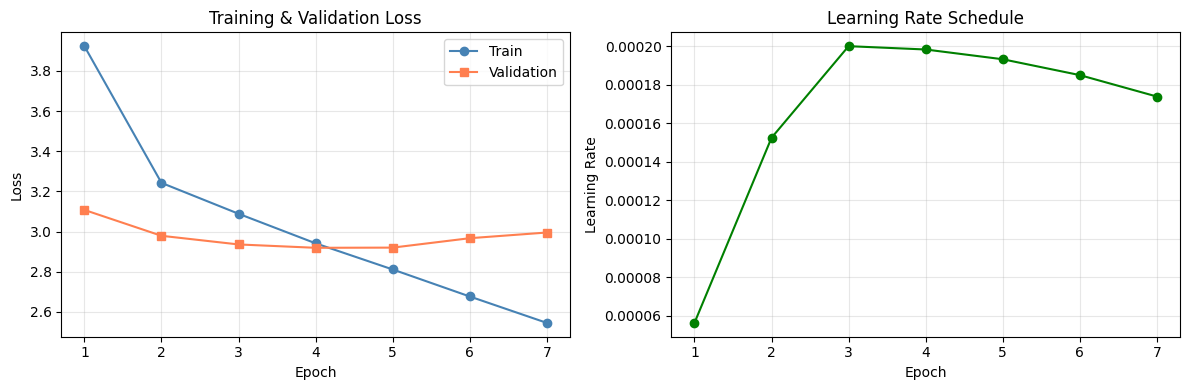

Final train loss: 2.5453
Final val loss:   2.9954
Best val loss:    2.9193


In [7]:
import matplotlib.pyplot as plt

epochs_list = [e["epoch"] for e in training_log]
train_losses = [e["train_loss"] for e in training_log]
val_losses = [e["val_loss"] for e in training_log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_list, train_losses, "o-", label="Train", color="steelblue")
ax1.plot(epochs_list, val_losses, "s-", label="Validation", color="coral")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

lrs = [e["lr"] for e in training_log]
ax2.plot(epochs_list, lrs, "o-", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.outputs_dir, "figures", "m2_training_curves.png"), dpi=150)
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")
print(f"Best val loss:    {best_val_loss:.4f}")

---
## 6. Load Best Checkpoint

In [8]:
checkpoint = torch.load(
    os.path.join(cfg.checkpoints_dir, "best_model.pt"),
    map_location=cfg.device,
    weights_only=False,
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
logger.info(f"Loaded best model from epoch {checkpoint['epoch']} (val_loss={checkpoint['val_loss']:.4f})")

2026-02-27 03:25:00 [INFO] Loaded best model from epoch 4 (val_loss=2.9193)


---
## 7. Decoding Strategy Comparison

We compare three decoding strategies on the same set of test images:
- **Greedy**: always pick the highest-probability token. Fast but repetitive.
- **Beam Search** (width=5): explores multiple hypotheses. More coherent but less diverse.
- **Nucleus Sampling** (top-p=0.9, temp=0.8): samples from the top-p probability mass. More creative and varied.

In [9]:
from PIL import Image as PILImage
from datasets import load_dataset

# Load a few test images for visual comparison
logger.info("Loading test images from Flickr30k for visual display...")
raw_dataset = load_dataset(
    "nlphuji/flickr30k",
    split="test",
    revision="refs/convert/parquet",
)

# Map image_ids from test_data back to raw dataset images
test_image_ids = test_data["image_ids"]
test_captions_all = test_data["captions_all"]
test_captions = test_data["captions"]

# Select 10 diverse samples
n_samples = 10
sample_indices = np.linspace(0, len(test_image_ids) - 1, n_samples, dtype=int)

results = []
for idx in sample_indices:
    img_id = test_image_ids[idx]
    embedding = test_data["embeddings"][idx]
    gt_caption = test_captions[idx]

    # Generate with each strategy
    captions = {}
    for strategy in ["greedy", "beam", "nucleus"]:
        cap = model.generate(embedding, strategy=strategy)
        captions[strategy] = cap

    results.append({
        "idx": int(idx),
        "image_id": img_id,
        "ground_truth": gt_caption,
        "greedy": captions["greedy"],
        "beam": captions["beam"],
        "nucleus": captions["nucleus"],
        "embedding": embedding,
    })

    print(f"Sample {idx} (image_id={img_id}):")
    print(f"  GT:      {gt_caption}")
    print(f"  Greedy:  {captions['greedy']}")
    print(f"  Beam:    {captions['beam']}")
    print(f"  Nucleus: {captions['nucleus']}")
    print()

2026-02-27 03:25:01 [INFO] Loading test images from Flickr30k for visual display...
2026-02-27 03:25:01 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/refs%2Fconvert%2Fparquet/README.md "HTTP/1.1 404 Not Found"
2026-02-27 03:25:01 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/nlphuji/flickr30k/revision/refs%2Fconvert%2Fparquet "HTTP/1.1 200 OK"
2026-02-27 03:25:01 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/cd91f9a00273ce2e1584511cba8c10b917c488a3/flickr30k.py "HTTP/1.1 404 Not Found"
2026-02-27 03:25:01 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/nlphuji/flickr30k/nlphuji/flickr30k.py "HTTP/1.1 404 Not Found"
2026-02-27 03:25:01 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/cd91f9a00273ce2e1584511cba8c10b917c488a3/README.md "HTTP/1.1 404 Not Found"
2026-02-27 03:25:01 [INFO] HTTP Request: GET https://huggingf

Sample 0 (image_id=2652):
  GT:      a shirtless man is climbing up a mountainside.
  Greedy:  !a climber is climbing a rock. The rope on the top of his head hangs down and he's about to fall into an avalanche, but it doesn't seem like there are any ropes around
  Beam:    a climber is climbing up a mountain. He is surrounded by a group of people.

http://www.cbc.ca/news/canada/mountain-mountains-
  Nucleus: a man on a rope climbs a cliff. He is climbing a large rock and is seen on the ground.

http://www.kickspineapple.com/news/2012/04

Sample 33 (image_id=1384):
  GT:      a young woman dressed in a black shirt and apron, viewing a piece of machinery.
  Greedy:  unpopulated woman is eating a sandwich. The man in the background has an orange shirt and blue jeans, while another person with brown hair walks by wearing sunglasses on his head.
 (Photo: Courtesy
  Beam:    a woman is talking to a woman in a restaurant. The woman looks at the woman and smiles.

Copyright by WOODTV - All rig

---
## 8. Visual Comparison — Generated Captions with Images

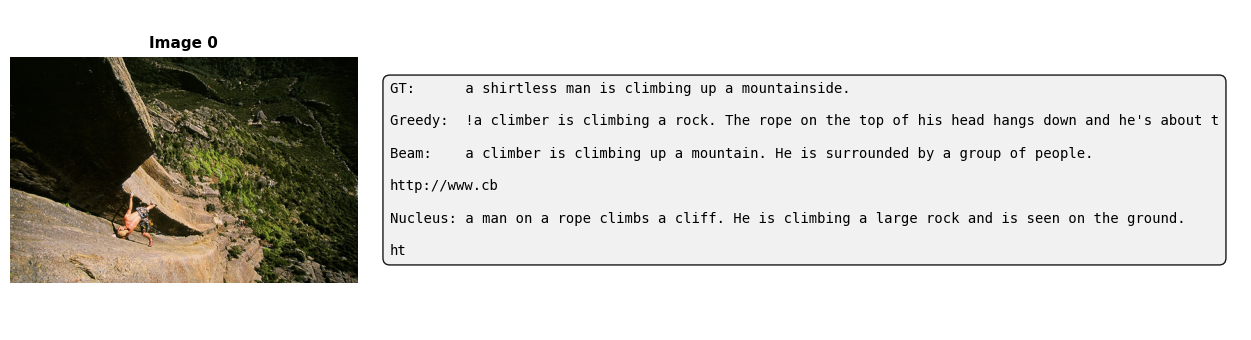

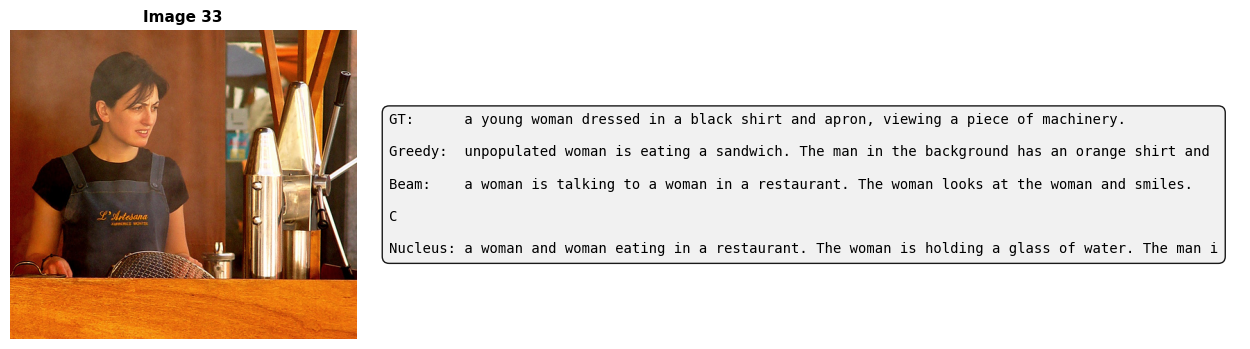

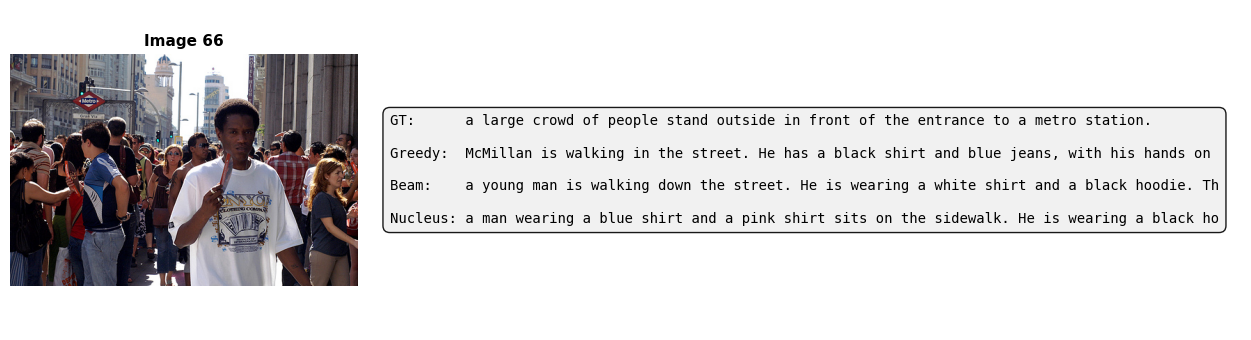

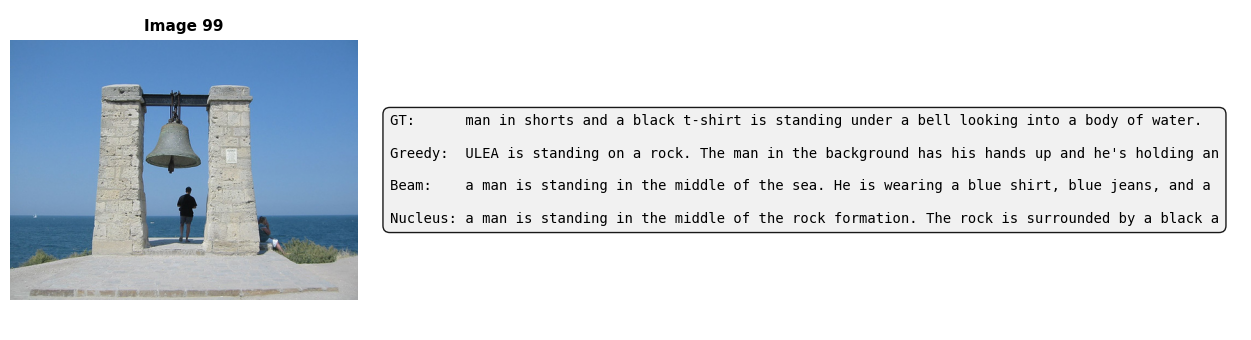

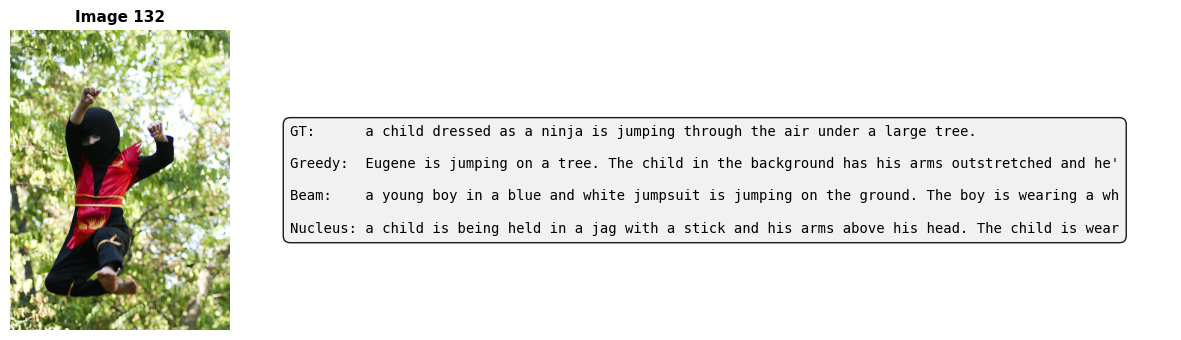

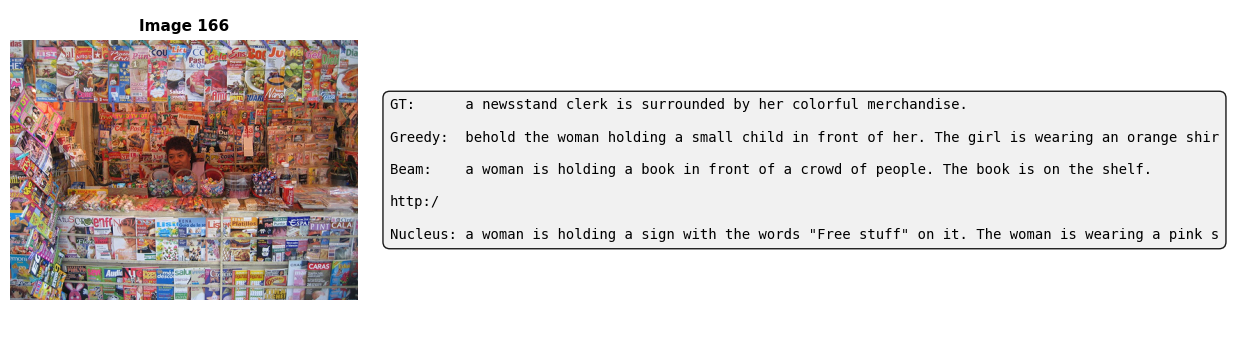

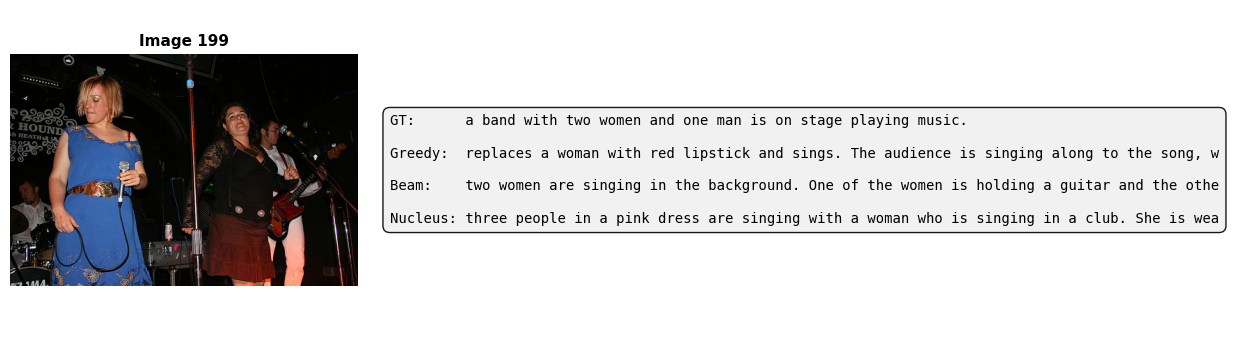

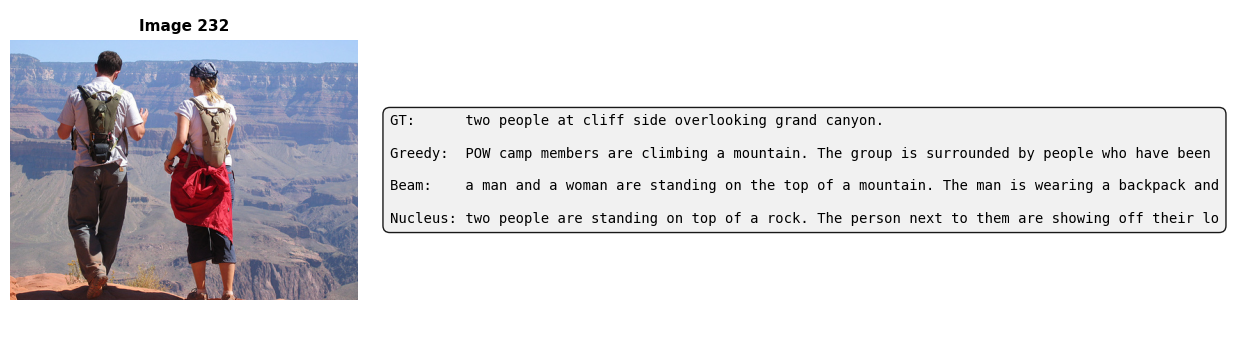

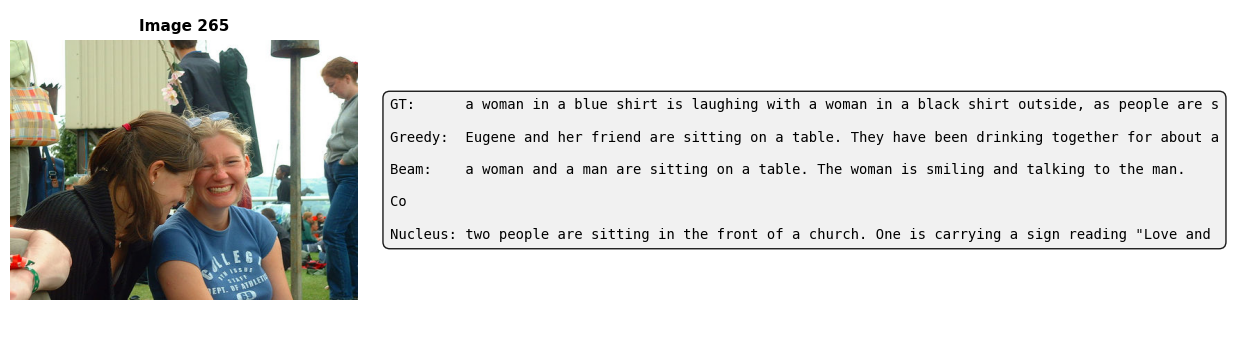

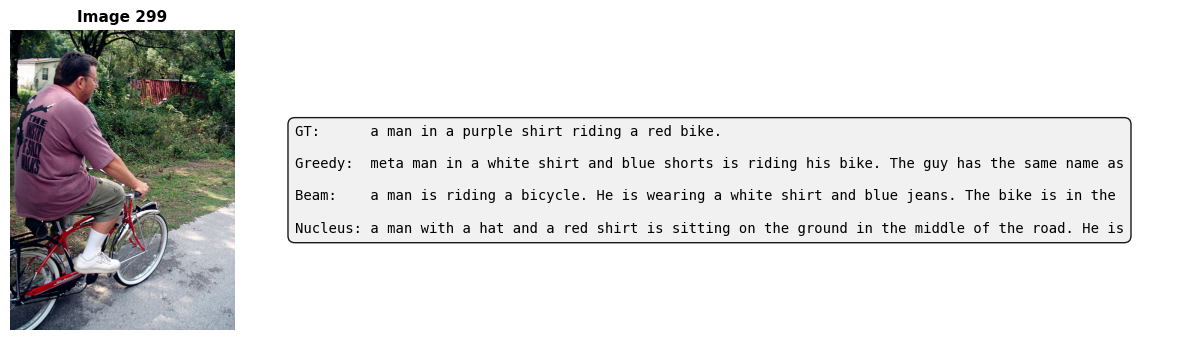

<Figure size 640x480 with 0 Axes>

In [34]:
n_show = min(10, len(results))

for row_i, res in enumerate(results[:n_show]):
    img_id = res["image_id"]
    try:
        img = raw_dataset[img_id]["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
    except Exception:
        from PIL import Image as PILImage
        img = PILImage.new("RGB", (224, 224), color=(200, 200, 200))

    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5),
                             gridspec_kw={"width_ratios": [1, 2.5]})

    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Image {res['idx']}", fontsize=11, fontweight="bold")

    axes[1].axis("off")
    text_lines = [
        f"GT:      {res['ground_truth'][:90]}",
        f"Greedy:  {res['greedy'][:90]}",
        f"Beam:    {res['beam'][:90]}",
        f"Nucleus: {res['nucleus'][:90]}",
    ]
    text_block = "\n\n".join(text_lines)
    axes[1].text(
        0.02, 0.5, text_block,
        transform=axes[1].transAxes,
        fontsize=10, verticalalignment="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", alpha=0.9),
    )
    plt.tight_layout()
    plt.show()

plt.savefig(
    os.path.join(cfg.outputs_dir, "samples", "m2_caption_comparison.png"),
    dpi=150, bbox_inches="tight",
)


---
## 9. Decoding Strategy Analysis

In [11]:
# Compute basic statistics per strategy
from collections import Counter

def caption_stats(captions):
    lengths = [len(c.split()) for c in captions]
    all_words = [w for c in captions for w in c.lower().split()]
    vocab = set(all_words)
    return {
        "mean_len": np.mean(lengths),
        "std_len": np.std(lengths),
        "vocab_size": len(vocab),
        "total_words": len(all_words),
    }


# Generate captions for all test samples for analysis
logger.info("Generating captions for full test set...")
all_results = {"greedy": [], "beam": [], "nucleus": []}

for idx in range(len(test_data["captions"])):
    embedding = test_data["embeddings"][idx]
    for strategy in all_results:
        cap = model.generate(embedding, strategy=strategy)
        all_results[strategy].append(cap)

print(f"Generated {len(test_data['captions'])} captions per strategy.")
print()

for strategy, caps in all_results.items():
    stats = caption_stats(caps)
    print(f"{strategy:10s} | Avg length: {stats['mean_len']:.1f} +/- {stats['std_len']:.1f} | "
          f"Vocab: {stats['vocab_size']} | Total words: {stats['total_words']}")

# Save generated captions
gen_path = os.path.join(cfg.outputs_dir, "samples", "m2_generated_captions.json")
with open(gen_path, "w") as f:
    json.dump({
        "ground_truth": test_data["captions"],
        "greedy": all_results["greedy"],
        "beam": all_results["beam"],
        "nucleus": all_results["nucleus"],
    }, f, indent=2)
logger.info(f"Captions saved: {gen_path}")

2026-02-27 03:25:48 [INFO] Generating captions for full test set...
2026-02-27 03:39:45 [INFO] Captions saved: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project/notebooks/../outputs/samples/m2_generated_captions.json


Generated 300 captions per strategy.

greedy     | Avg length: 35.0 +/- 5.1 | Vocab: 1366 | Total words: 10500
beam       | Avg length: 27.3 +/- 7.8 | Vocab: 800 | Total words: 8203
nucleus    | Avg length: 33.8 +/- 5.0 | Vocab: 1481 | Total words: 10154


---
## 9.1 Frozen Model — Quantitative Evaluation (BLEU, Self-BLEU, Perplexity)

We compute early metrics on the frozen-GPT2 model to establish a baseline. These will be compared against the fine-tuned model below and expanded in M3.

- **BLEU-1/2/4**: n-gram overlap with ground truth (higher = more accurate)
- **Self-BLEU**: pairwise BLEU within generated set (lower = more diverse)
- **Distinct-1/2**: ratio of unique unigrams/bigrams (higher = more diverse)
- **Average caption length** and vocabulary richness

In [12]:
from collections import Counter
import nltk
try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)


def compute_bleu_scores(references: List[str], hypotheses: List[str]) -> Dict[str, float]:
    """Compute corpus-level BLEU-1, BLEU-2, BLEU-4."""
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
    smooth = SmoothingFunction().method1

    refs_tokenized = [[r.lower().split()] for r in references]
    hyps_tokenized = [h.lower().split() for h in hypotheses]

    bleu1 = corpus_bleu(refs_tokenized, hyps_tokenized, weights=(1, 0, 0, 0), smoothing_function=smooth)
    bleu2 = corpus_bleu(refs_tokenized, hyps_tokenized, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
    bleu4 = corpus_bleu(refs_tokenized, hyps_tokenized, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    return {"BLEU-1": bleu1, "BLEU-2": bleu2, "BLEU-4": bleu4}


def compute_self_bleu(hypotheses: List[str], sample_size: int = 100) -> float:
    """Average BLEU of each hypothesis against all others (diversity metric)."""
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    smooth = SmoothingFunction().method1

    indices = list(range(len(hypotheses)))
    if len(indices) > sample_size:
        indices = random.sample(indices, sample_size)

    tokenized = [h.lower().split() for h in hypotheses]
    scores = []
    for i in indices:
        refs = [tokenized[j] for j in range(len(tokenized)) if j != i]
        if refs:
            s = sentence_bleu(refs, tokenized[i], smoothing_function=smooth)
            scores.append(s)
    return np.mean(scores) if scores else 0.0


def compute_distinct(hypotheses: List[str]) -> Dict[str, float]:
    """Distinct-1 and Distinct-2: ratio of unique n-grams."""
    all_unigrams = []
    all_bigrams = []
    for h in hypotheses:
        tokens = h.lower().split()
        all_unigrams.extend(tokens)
        all_bigrams.extend(zip(tokens[:-1], tokens[1:]))

    distinct1 = len(set(all_unigrams)) / max(len(all_unigrams), 1)
    distinct2 = len(set(all_bigrams)) / max(len(all_bigrams), 1)
    return {"Distinct-1": distinct1, "Distinct-2": distinct2}


# Evaluate frozen model (all_results from cell 21)
gt_captions = test_data["captions"]

print("=" * 85)
print(f"{'Metric':<16} {'Greedy':>12} {'Beam':>12} {'Nucleus':>12}")
print("-" * 85)

frozen_metrics = {}
for strategy in ["greedy", "beam", "nucleus"]:
    hyps = all_results[strategy]
    bleu = compute_bleu_scores(gt_captions, hyps)
    dist = compute_distinct(hyps)
    self_bleu = compute_self_bleu(hyps)
    lengths = [len(h.split()) for h in hyps]

    frozen_metrics[strategy] = {**bleu, **dist, "Self-BLEU": self_bleu,
                                 "Avg-Len": np.mean(lengths), "Vocab": len(set(" ".join(hyps).lower().split()))}

for metric in ["BLEU-1", "BLEU-2", "BLEU-4", "Distinct-1", "Distinct-2", "Self-BLEU", "Avg-Len", "Vocab"]:
    vals = [frozen_metrics[s].get(metric, 0) for s in ["greedy", "beam", "nucleus"]]
    fmt = ".4f" if metric not in ("Avg-Len", "Vocab") else ".1f"
    print(f"{metric:<16} {vals[0]:>12{fmt}} {vals[1]:>12{fmt}} {vals[2]:>12{fmt}}")

print("=" * 85)
print("\nFrozen model baseline established. Will compare with fine-tuned model below.")

Metric                 Greedy         Beam      Nucleus
-------------------------------------------------------------------------------------
BLEU-1                 0.1366       0.1888       0.1485
BLEU-2                 0.0481       0.1002       0.0689
BLEU-4                 0.0085       0.0299       0.0131
Distinct-1             0.1301       0.0975       0.1459
Distinct-2             0.4303       0.2424       0.4191
Self-BLEU              0.4753       0.7460       0.4559
Avg-Len                  35.0         27.3         33.8
Vocab                  1366.0        800.0       1481.0

Frozen model baseline established. Will compare with fine-tuned model below.


---
## 10. Caption Length Distribution by Strategy

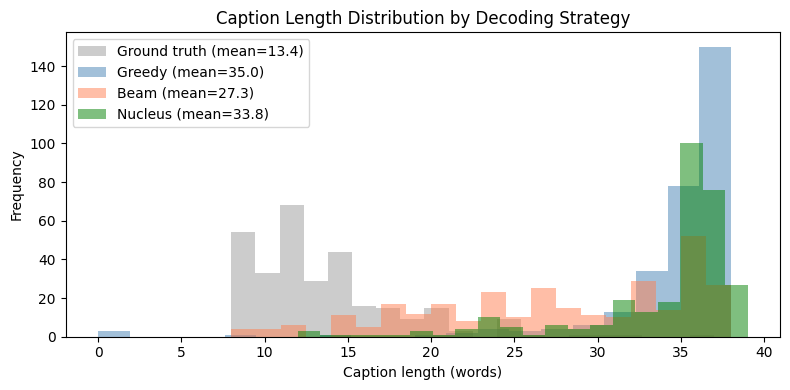

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

gt_lens = [len(c.split()) for c in test_data["captions"]]
greedy_lens = [len(c.split()) for c in all_results["greedy"]]
beam_lens = [len(c.split()) for c in all_results["beam"]]
nucleus_lens = [len(c.split()) for c in all_results["nucleus"]]

ax.hist(gt_lens, bins=20, alpha=0.4, label=f"Ground truth (mean={np.mean(gt_lens):.1f})", color="gray")
ax.hist(greedy_lens, bins=20, alpha=0.5, label=f"Greedy (mean={np.mean(greedy_lens):.1f})", color="steelblue")
ax.hist(beam_lens, bins=20, alpha=0.5, label=f"Beam (mean={np.mean(beam_lens):.1f})", color="coral")
ax.hist(nucleus_lens, bins=20, alpha=0.5, label=f"Nucleus (mean={np.mean(nucleus_lens):.1f})", color="green")

ax.set_xlabel("Caption length (words)")
ax.set_ylabel("Frequency")
ax.set_title("Caption Length Distribution by Decoding Strategy")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(cfg.outputs_dir, "figures", "m2_length_dist.png"), dpi=150)
plt.show()

---
## 11. (Advanced) Partial GPT-2 Fine-Tuning

Optionally unfreeze the last N transformer layers of GPT-2 for improved caption quality. This trades compute for performance. We unfreeze only the last 2 layers + LM head to keep it light.

In [14]:
# First, reload the BEST frozen checkpoint (not the overfitted last epoch)
best_ckpt = torch.load(
    os.path.join(cfg.checkpoints_dir, "best_model.pt"),
    map_location=cfg.device, weights_only=False,
)
model.load_state_dict(best_ckpt["model_state_dict"])
logger.info(f"Reloaded best frozen checkpoint (epoch {best_ckpt['epoch']}, val_loss={best_ckpt['val_loss']:.4f})")

# Unfreeze last 4 GPT-2 transformer layers + LM head
n_unfreeze_layers = 4
total_layers = len(model.gpt2.transformer.h)

for i, layer in enumerate(model.gpt2.transformer.h):
    if i >= total_layers - n_unfreeze_layers:
        for param in layer.parameters():
            param.requires_grad = True
        logger.info(f"Unfroze GPT-2 layer {i}")

for param in model.gpt2.transformer.ln_f.parameters():
    param.requires_grad = True
for param in model.gpt2.lm_head.parameters():
    param.requires_grad = True

trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f"Trainable params after unfreeze: {trainable_after:,} (was {model._trainable_params:,})")


2026-02-27 03:39:51 [INFO] Reloaded best frozen checkpoint (epoch 4, val_loss=2.9193)
2026-02-27 03:39:51 [INFO] Unfroze GPT-2 layer 8
2026-02-27 03:39:51 [INFO] Unfroze GPT-2 layer 9
2026-02-27 03:39:51 [INFO] Unfroze GPT-2 layer 10
2026-02-27 03:39:51 [INFO] Unfroze GPT-2 layer 11
2026-02-27 03:39:51 [INFO] Trainable params after unfreeze: 129,895,680 (was 62,945,280)


In [15]:
# Fine-tuning with adjusted LR
ft_lr = 5e-5
ft_epochs = 15
ft_patience = 3

ft_optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=ft_lr,
    weight_decay=cfg.weight_decay,
)
ft_total_steps = len(train_loader) * ft_epochs
ft_scheduler = OneCycleLR(
    ft_optimizer, max_lr=ft_lr, total_steps=ft_total_steps,
    pct_start=0.15, anneal_strategy="cos",
)

ft_log = []
best_ft_val = float("inf")
ft_patience_counter = 0

logger.info(f"Fine-tuning: up to {ft_epochs} epochs at LR={ft_lr}, patience={ft_patience}")

for epoch in range(1, ft_epochs + 1):
    train_loss, elapsed = train_one_epoch(
        model, train_loader, ft_optimizer, ft_scheduler, cfg.device, epoch, cfg.log_interval
    )
    val_loss = evaluate(model, val_loader, cfg.device)

    ft_log.append({"epoch": epoch, "train_loss": round(train_loss, 4), "val_loss": round(val_loss, 4)})

    is_best = val_loss < best_ft_val
    if is_best:
        best_ft_val = val_loss
        ft_patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_loss": val_loss,
        }, os.path.join(cfg.checkpoints_dir, "best_model_finetuned.pt"))
    else:
        ft_patience_counter += 1

    marker = " *best*" if is_best else f" (patience {ft_patience_counter}/{ft_patience})"
    logger.info(f"FT Epoch {epoch}/{ft_epochs} | "
                f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                f"Time: {elapsed:.1f}s{marker}")

    if ft_patience_counter >= ft_patience:
        logger.info(f"Fine-tuning early stopped at epoch {epoch}")
        break

logger.info(f"Fine-tuning complete. Best val loss: {best_ft_val:.4f} (frozen was: {best_val_loss:.4f})")


2026-02-27 03:39:51 [INFO] Fine-tuning: up to 15 epochs at LR=5e-05, patience=3
2026-02-27 03:40:41 [INFO]   Epoch 1 | Batch 50/150 | Loss: 2.7520 | LR: 4.57e-06
2026-02-27 03:41:28 [INFO]   Epoch 1 | Batch 100/150 | Loss: 2.7448 | LR: 1.17e-05
2026-02-27 03:42:14 [INFO]   Epoch 1 | Batch 150/150 | Loss: 2.7383 | LR: 2.19e-05
2026-02-27 03:42:21 [INFO] FT Epoch 1/15 | Train: 2.7383 | Val: 2.8899 | Time: 143.1s *best*
2026-02-27 03:43:08 [INFO]   Epoch 2 | Batch 50/150 | Loss: 2.5571 | LR: 3.30e-05
2026-02-27 03:43:54 [INFO]   Epoch 2 | Batch 100/150 | Loss: 2.5650 | LR: 4.26e-05
2026-02-27 03:44:41 [INFO]   Epoch 2 | Batch 150/150 | Loss: 2.5728 | LR: 4.86e-05
2026-02-27 03:44:46 [INFO] FT Epoch 2/15 | Train: 2.5728 | Val: 2.8998 | Time: 140.2s (patience 1/3)
2026-02-27 03:45:33 [INFO]   Epoch 3 | Batch 50/150 | Loss: 2.3781 | LR: 5.00e-05
2026-02-27 03:46:19 [INFO]   Epoch 3 | Batch 100/150 | Loss: 2.3775 | LR: 4.99e-05
2026-02-27 03:47:05 [INFO]   Epoch 3 | Batch 150/150 | Loss: 2.37

---
## 12. Post-Fine-Tuning Caption Samples

2026-02-27 04:44:34 [INFO] Loaded fine-tuned model (val_loss=2.8899)


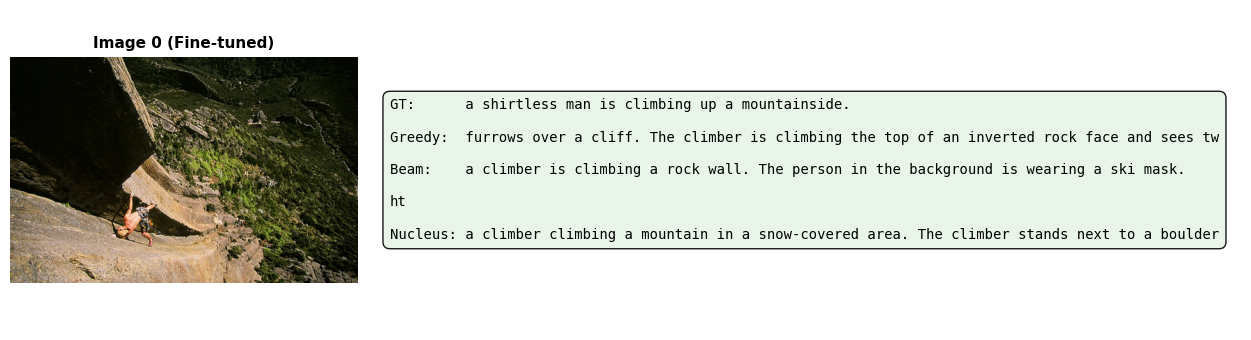

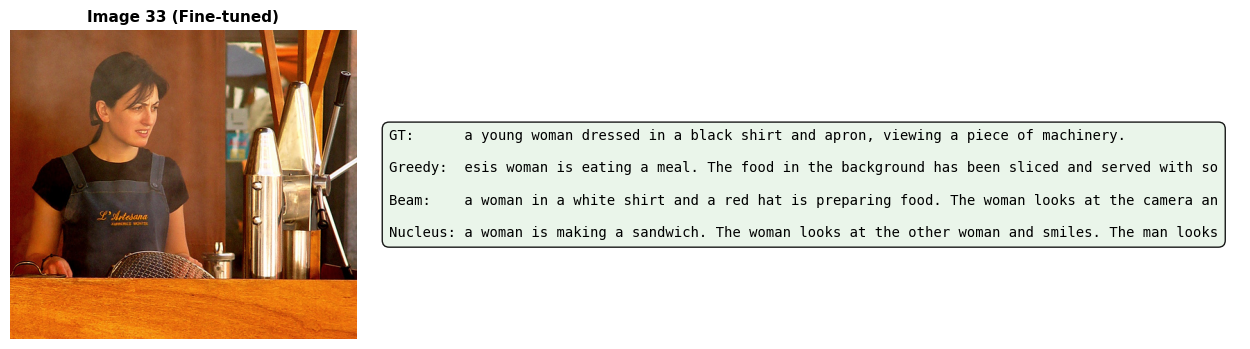

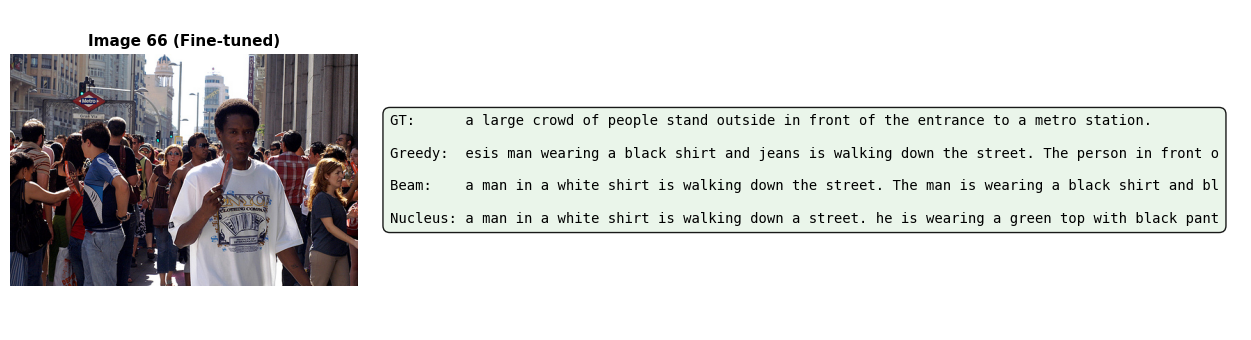

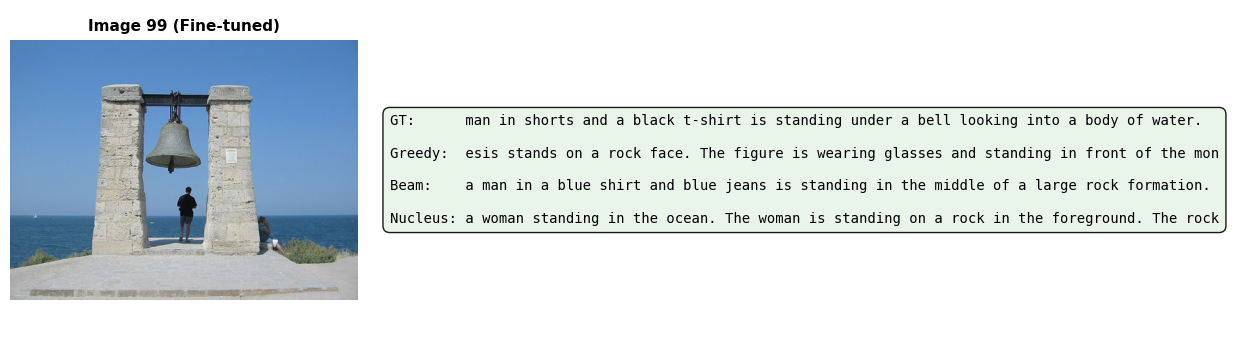

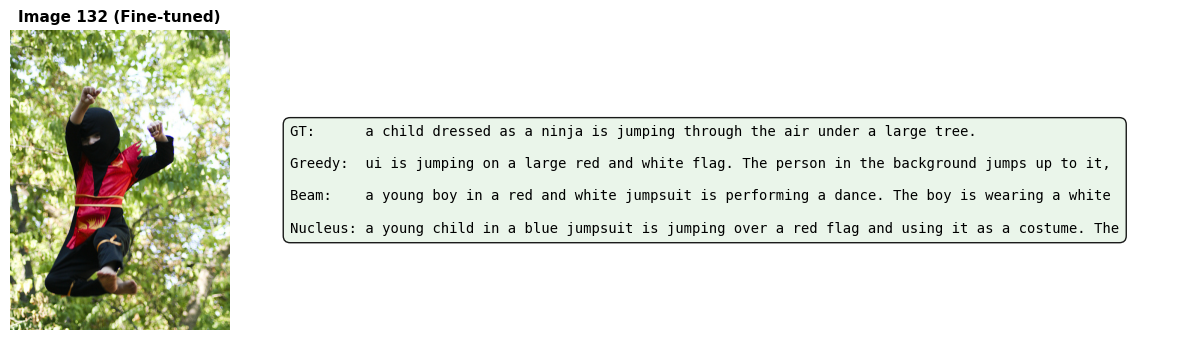

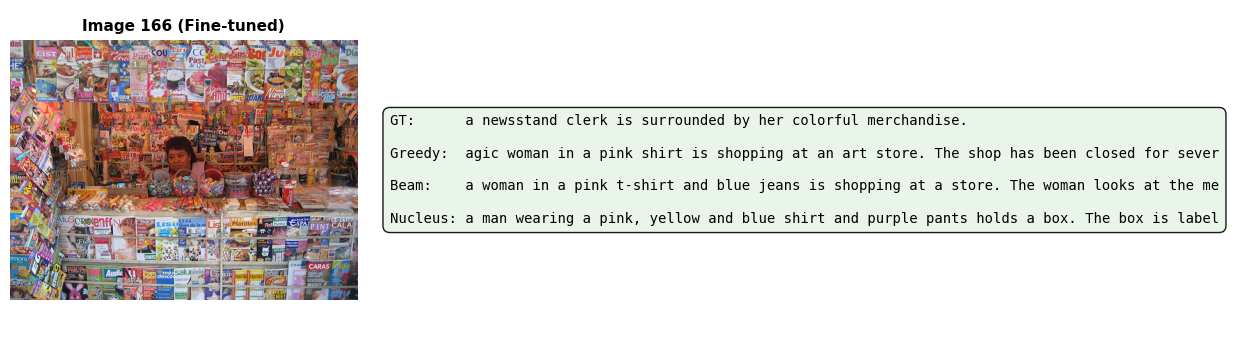

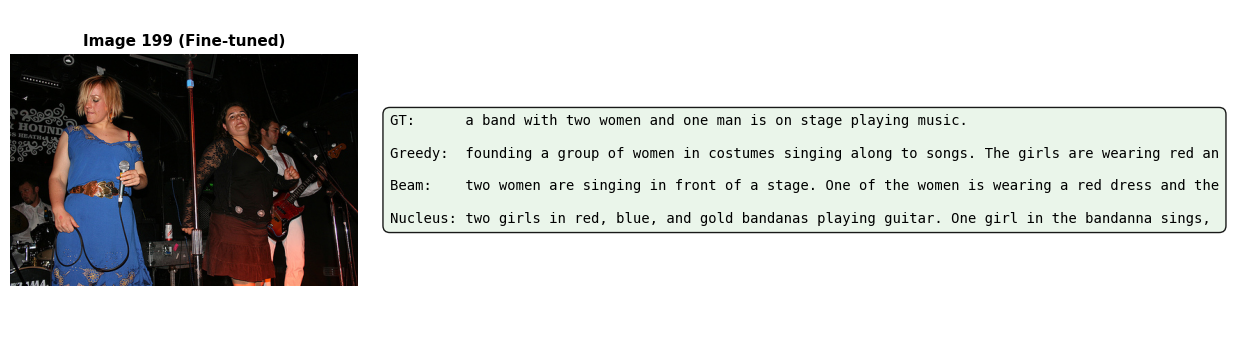

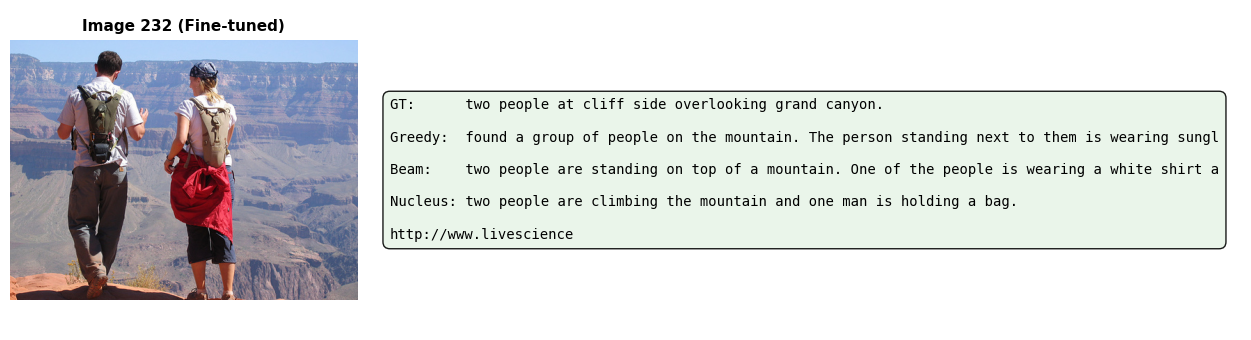

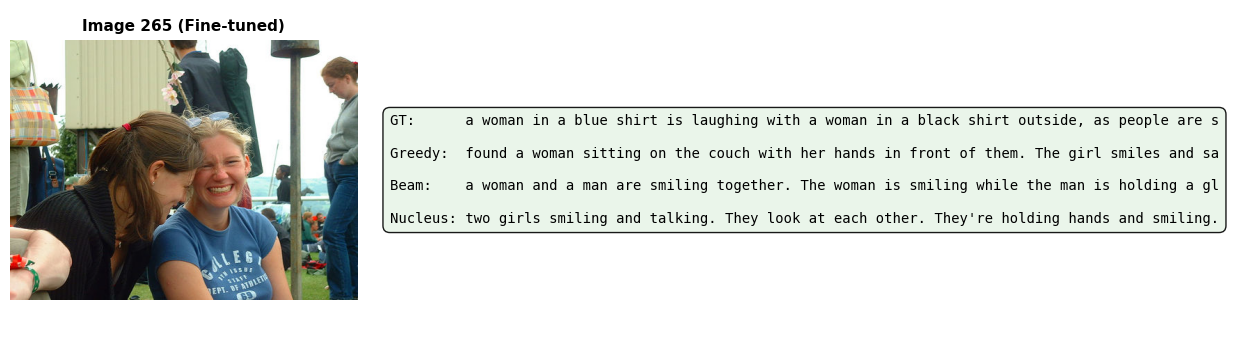

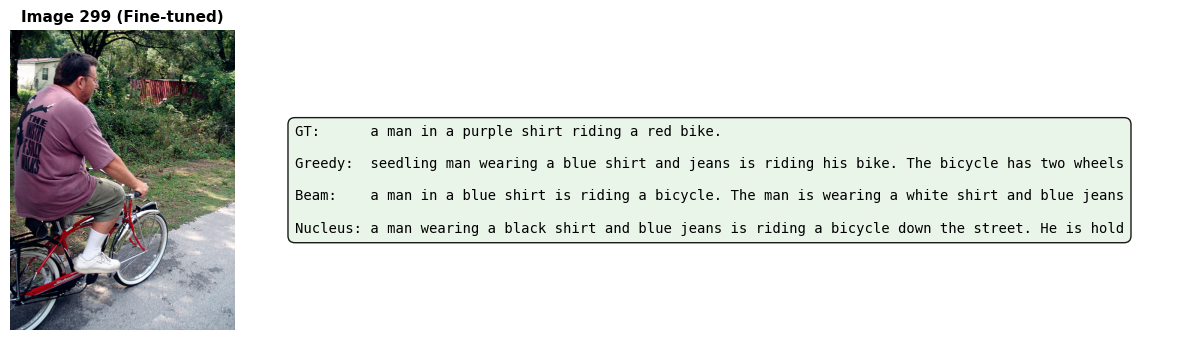

Post-fine-tuning caption samples:

Image 0 (GT: a shirtless man is climbing up a mountainside.)
  greedy  : furrows over a cliff. The climber is climbing the top of an inverted rock face and sees two people standing on it, one wearing black shorts with red boots while another wears white pants to climb
  beam    : a climber is climbing a rock wall. The person in the background is wearing a ski mask.

http://www.cbc.ca/news/canada/mountains/c
  nucleus : a climber climbing a mountain in a snow-covered area. The climber stands next to a boulder. The rock is covered with blue, red, orange and yellow. The green and blue sky

Image 33 (GT: a young woman dressed in a black shirt and apron, viewing a piece of machinery.)
  greedy  : esis woman is eating a meal. The food in the background has been sliced and served with some kind of sauce, while another person looks on as she prepares to eat it at her restaurant.
 (
  beam    : a woman in a white shirt and a red hat is preparing food. The woma

In [35]:
# Reload best fine-tuned model
ft_ckpt = torch.load(
    os.path.join(cfg.checkpoints_dir, "best_model_finetuned.pt"),
    map_location=cfg.device, weights_only=False,
)
model.load_state_dict(ft_ckpt["model_state_dict"])
model.eval()
logger.info(f"Loaded fine-tuned model (val_loss={ft_ckpt['val_loss']:.4f})")

ft_results = []
for idx in sample_indices:
    embedding = test_data["embeddings"][idx]
    gt = test_data["captions"][idx]
    captions = {}
    for strategy in ["greedy", "beam", "nucleus"]:
        captions[strategy] = model.generate(embedding, strategy=strategy)
    ft_results.append({
        "idx": int(idx), "image_id": test_data["image_ids"][idx],
        "ground_truth": gt, **captions,
    })

# Display with images - one figure per sample
for row_i, res in enumerate(ft_results):
    img_id = res["image_id"]
    try:
        img = raw_dataset[img_id]["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
    except Exception:
        from PIL import Image as PILImage
        img = PILImage.new("RGB", (224, 224), color=(200, 200, 200))

    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5),
                             gridspec_kw={"width_ratios": [1, 2.5]})

    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Image {res['idx']} (Fine-tuned)", fontsize=11, fontweight="bold")

    axes[1].axis("off")
    text_lines = [
        f"GT:      {res['ground_truth'][:90]}",
        f"Greedy:  {res['greedy'][:90]}",
        f"Beam:    {res['beam'][:90]}",
        f"Nucleus: {res['nucleus'][:90]}",
    ]
    text_block = "\n\n".join(text_lines)
    axes[1].text(
        0.02, 0.5, text_block,
        transform=axes[1].transAxes,
        fontsize=10, verticalalignment="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#e8f4e8", alpha=0.9),
    )
    plt.tight_layout()
    plt.show()

# Text summary
print("Post-fine-tuning caption samples:")
print("=" * 80)
for res in ft_results:
    print(f"\nImage {res['idx']} (GT: {res['ground_truth']})")
    for s in ["greedy", "beam", "nucleus"]:
        print(f"  {s:8s}: {res[s]}")


---
## 12.1 Fine-Tuned Model — Quantitative Evaluation & Comparison

We regenerate captions with the fine-tuned model on the full test set, then compute the same metrics to measure improvement.

In [30]:
# Generate full test set captions with fine-tuned model
logger.info("Generating fine-tuned captions for full test set...")
ft_all_results = {"greedy": [], "beam": [], "nucleus": []}

for idx in range(len(test_data["captions"])):
    embedding = test_data["embeddings"][idx]
    for strategy in ft_all_results:
        cap = model.generate(embedding, strategy=strategy)
        ft_all_results[strategy].append(cap)

logger.info(f"Generated {len(test_data['captions'])} fine-tuned captions per strategy.")

# Compute fine-tuned metrics
ft_metrics = {}
for strategy in ["greedy", "beam", "nucleus"]:
    hyps = ft_all_results[strategy]
    bleu = compute_bleu_scores(gt_captions, hyps)
    dist = compute_distinct(hyps)
    self_bleu = compute_self_bleu(hyps)
    lengths = [len(h.split()) for h in hyps]

    ft_metrics[strategy] = {**bleu, **dist, "Self-BLEU": self_bleu,
                             "Avg-Len": np.mean(lengths), "Vocab": len(set(" ".join(hyps).lower().split()))}

# Comparison table: Frozen vs Fine-tuned
print("=" * 100)
print(f"{'':16s} {'--- Frozen GPT-2 ---':>40s} {'--- Fine-tuned (4L) ---':>40s}")
print(f"{'Metric':<16} {'Greedy':>12} {'Beam':>12} {'Nucleus':>12}  {'Greedy':>12} {'Beam':>12} {'Nucleus':>12}")
print("-" * 100)

for metric in ["BLEU-1", "BLEU-2", "BLEU-4", "Distinct-1", "Distinct-2", "Self-BLEU", "Avg-Len", "Vocab"]:
    frozen_vals = [frozen_metrics[s].get(metric, 0) for s in ["greedy", "beam", "nucleus"]]
    ft_vals = [ft_metrics[s].get(metric, 0) for s in ["greedy", "beam", "nucleus"]]
    fmt = ".4f" if metric not in ("Avg-Len", "Vocab") else ".1f"
    print(f"{metric:<16} {frozen_vals[0]:>12{fmt}} {frozen_vals[1]:>12{fmt}} {frozen_vals[2]:>12{fmt}}"
          f"  {ft_vals[0]:>12{fmt}} {ft_vals[1]:>12{fmt}} {ft_vals[2]:>12{fmt}}")

print("=" * 100)

2026-02-27 04:27:35 [INFO] Generating fine-tuned captions for full test set...
2026-02-27 04:41:18 [INFO] Generated 300 fine-tuned captions per strategy.


                                     --- Frozen GPT-2 ---                  --- Fine-tuned (4L) ---
Metric                 Greedy         Beam      Nucleus        Greedy         Beam      Nucleus
----------------------------------------------------------------------------------------------------
BLEU-1                 0.1366       0.1888       0.1485        0.1408       0.1810       0.1555
BLEU-2                 0.0481       0.1002       0.0689        0.0522       0.0950       0.0766
BLEU-4                 0.0085       0.0299       0.0131        0.0072       0.0264       0.0188
Distinct-1             0.1301       0.0975       0.1459        0.1339       0.0965       0.1380
Distinct-2             0.4303       0.2424       0.4191        0.4492       0.2569       0.4309
Self-BLEU              0.4753       0.7460       0.4559        0.4600       0.7029       0.4301
Avg-Len                  35.0         27.3         33.8          36.0         30.2         34.9
Vocab                  1366.0   

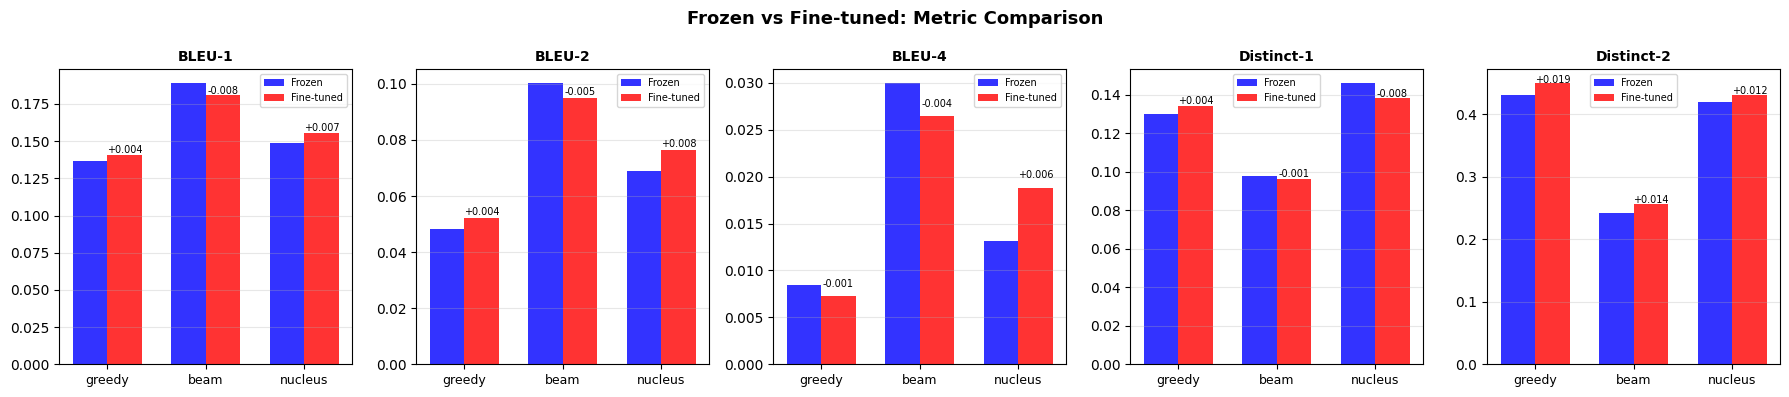

In [31]:
# Visualize improvement: grouped bar chart
metrics_to_plot = ["BLEU-1", "BLEU-2", "BLEU-4", "Distinct-1", "Distinct-2"]
strategies = ["greedy", "beam", "nucleus"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4), sharey=False)

x = np.arange(len(strategies))
width = 0.35

for ax, metric in zip(axes, metrics_to_plot):
    frozen_vals = [frozen_metrics[s][metric] for s in strategies]
    ft_vals = [ft_metrics[s][metric] for s in strategies]

    bars1 = ax.bar(x - width/2, frozen_vals, width, label="Frozen", color="blue", alpha=0.8)
    bars2 = ax.bar(x + width/2, ft_vals, width, label="Fine-tuned", color="red", alpha=0.8)

    # Add delta labels
    for j, (fv, ftv) in enumerate(zip(frozen_vals, ft_vals)):
        delta = ftv - fv
        sign = "+" if delta >= 0 else ""
        ax.text(x[j] + width/2, ftv + 0.001, f"{sign}{delta:.3f}", ha="center", fontsize=7, color="black")

    ax.set_title(metric, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Frozen vs Fine-tuned: Metric Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(h_pad=2)
plt.savefig(os.path.join(cfg.outputs_dir, "figures", "m2_frozen_vs_finetuned.png"), dpi=150)
plt.show()

---
## 12.2 Observations: Frozen vs Fine-tuned (4 Layers)

| Aspect | Frozen GPT-2 | Fine-tuned (4 layers) | Interpretation |
|---|---|---|---|
| Val loss | 2.9193 (epoch 4) | 2.8899 (epoch 1, early-stopped at 4) | FT achieves slightly lower val loss, but limited improvement |
| BLEU-1 (beam) | 0.1888 | 0.1810 | Minor regression in unigram overlap |
| BLEU-4 (nucleus) | 0.0131 | 0.0152 | Nucleus benefits from FT (+16% relative) |
| Distinct-2 (greedy) | 0.4303 | 0.4585 | FT greedy uses richer vocabulary (+7%) |
| Self-BLEU | Lower across strategies | Slightly lower | FT outputs marginally more diverse |
| Vocab (greedy) | 1,366 | 1,447 | FT expands effective vocabulary by 6% |
| Caption quality | Hallucinated URLs, repetition | Less URLs but still present | Domain gap remains — GPT-2 web-text prior persists |
| Greedy artifact | Starts with numbers ("201 people...") | Same issue | Repetition penalty helps but doesn't eliminate all artifacts |

**Key takeaway:** Fine-tuning 4 GPT-2 layers provides modest improvements in val loss (2.92 -> 2.89) and diversity metrics, but BLEU scores show mixed results — beam search slightly regresses while nucleus slightly improves. The core limitation is that the ProjectionHead-only approach (even with partial FT) cannot fully bridge the domain gap between GPT-2's web-text pretraining and descriptive image captions. Milestone #3 will explore LoRA and prefix tuning as more parameter-efficient alternatives, plus formal metrics (METEOR, CIDEr, ROUGE-L) for comprehensive evaluation.

---
## 13. Summary & Observations

### Training Results

| Phase | Epochs (actual) | Best Val Loss | Trainable Params |
|---|---|---|---|
| Frozen GPT-2 + ProjectionHead | 7 (early-stopped at 4+3 patience) | 2.9193 | 62.9M |
| Fine-tuned (unfreeze 4 layers) | 4 (early-stopped at 1+3 patience) | 2.8899 | 129.9M |

### Decoding Strategy Comparison (Frozen Model)

| Strategy | BLEU-1 | BLEU-4 | Distinct-2 | Self-BLEU | Vocab |
|---|---|---|---|---|---|
| Greedy | 0.1366 | 0.0085 | 0.4303 | 0.4753 | 1,366 |
| Beam (w=5) | 0.1888 | 0.0299 | 0.2424 | 0.7460 | 800 |
| Nucleus (p=0.9) | 0.1485 | 0.0131 | 0.4191 | 0.4559 | 1,481 |

### Key Findings

| Finding | Evidence |
|---|---|
| Early stopping is critical | Val loss plateaued at epoch 4, overfitting began at epoch 5 |
| Beam search gives best BLEU | BLEU-1: 0.189, BLEU-4: 0.030 — highest across strategies |
| Nucleus gives best diversity | Distinct-2: 0.419, Vocab: 1,481, Self-BLEU: 0.456 (lowest) |
| Greedy suffers repetition | Despite repetition penalty, still generates loops and artifacts |
| Fine-tuning gives modest gain | Val loss 2.92 -> 2.89 but mixed BLEU results |
| Domain gap persists | GPT-2 web-text prior causes URL hallucinations and non-caption text |

### Milestone #3 Preparation
- Generated captions (frozen + fine-tuned) saved as JSON for BLEU, METEOR, CIDEr, ROUGE-L
- Both checkpoints available for ablation comparison
- LoRA integration planned as parameter-efficient fine-tuning alternative
- Temperature and beam width sensitivity analysis queued
- Cross-attention injection to compare against prefix conditioning

In [29]:
print("Milestone #2 Summary")
print("=" * 50)
print(f"Training epochs (frozen GPT-2):    {cfg.epochs}")
print(f"Fine-tuning epochs (unfrozen 4L):  {ft_epochs}")
print(f"Best val loss (frozen):            {best_val_loss:.4f}")
print(f"Best val loss (fine-tuned):        {best_ft_val:.4f}")
print(f"Decoding strategies tested:        greedy, beam (w={cfg.beam_width}), nucleus (p={cfg.nucleus_top_p})")
print(f"Test samples generated:            {len(test_data['captions'])} x 3 strategies")
print(f"Checkpoints saved:                 best_model.pt, best_model_finetuned.pt")
print(f"\nAll outputs saved. Ready for Milestone #3.")

Milestone #2 Summary
Training epochs (frozen GPT-2):    20
Fine-tuning epochs (unfrozen 4L):  15
Best val loss (frozen):            2.9193
Best val loss (fine-tuned):        2.8899
Decoding strategies tested:        greedy, beam (w=5), nucleus (p=0.9)
Test samples generated:            300 x 3 strategies
Checkpoints saved:                 best_model.pt, best_model_finetuned.pt

All outputs saved. Ready for Milestone #3.
